# Dia 6  Serie temporal climatica de 12 meses

Objetivo: Construir serie climatica desde 2025-08-23 a 2026-08-22.

In [19]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

## Configuracion de la consulta y Obtencion de datos

In [20]:
json_path = '../data/raw/nasa_power/POWER_Point_Daily_20250823_20260822_001d72S_078d76W_LST.json'
with open(json_path, 'r') as f:
    data = json.load(f)
print('Claves obtenidas:', data['properties']['parameter'].keys())

Claves obtenidas: dict_keys(['T2M', 'RH2M', 'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN'])


## Conversion a DataFrame y Limpieza

In [21]:
params = data['properties']['parameter']
df = pd.DataFrame(params).reset_index().rename(columns={'index': 'fecha'})
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m%d')
df = df.replace(-999.0, np.nan)

## Calculo de VPD

In [22]:
def calculate_vpd(T, RH):
    RH_decimal = RH / 100
    return 0.6108 * np.exp((17.27 * T) / (T + 237.3)) * (1 - RH_decimal)

df['VPD'] = calculate_vpd(df['T2M'], df['RH2M'])
df.head()

,fecha,T2M,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,VPD
0,2025-08-23,10.76,84.77,6.55,13.10,0.196759
1,2025-08-24,10.25,82.67,4.63,14.74,0.216397
2,2025-08-25,10.26,84.89,4.52,9.58,0.188803
3,2025-08-26,10.93,84.09,2.75,13.84,0.207883
4,2025-08-27,9.91,84.72,1.02,10.52,0.186504


## Validaciones (Periodo, -999, etc.)

In [23]:
rango = pd.date_range(start='2025-08-23', end='2026-08-22')
print('Filas:', len(df))
print('Missing 999:', (df == -999.0).sum().sum())
print('NaN:\n', df.isna().sum())

Filas: 365
Missing 999: 0
NaN:
 fecha                0
T2M                  0
RH2M                 0
PRECTOTCORR          0
ALLSKY_SFC_SW_DWN    2
VPD                  0
dtype: int64


## Estadisticas descriptivas

In [24]:
df[['T2M', 'RH2M', 'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'VPD']].describe()

,T2M,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,VPD
count,365.000000,365.000000,365.000000,363.000000,365.000000
mean,11.447644,87.084384,5.028000,14.180634,0.174487
std,0.716151,2.556728,4.932376,3.159787,0.033338
min,9.290000,78.550000,0.000000,5.420000,0.086803
25%,10.950000,85.370000,1.670000,12.085000,0.152669
50%,11.450000,87.070000,3.640000,14.030000,0.178473
75%,11.960000,88.930000,6.860000,15.855000,0.197019
max,13.650000,93.200000,37.210000,24.560000,0.282895


## Graficos: T2M

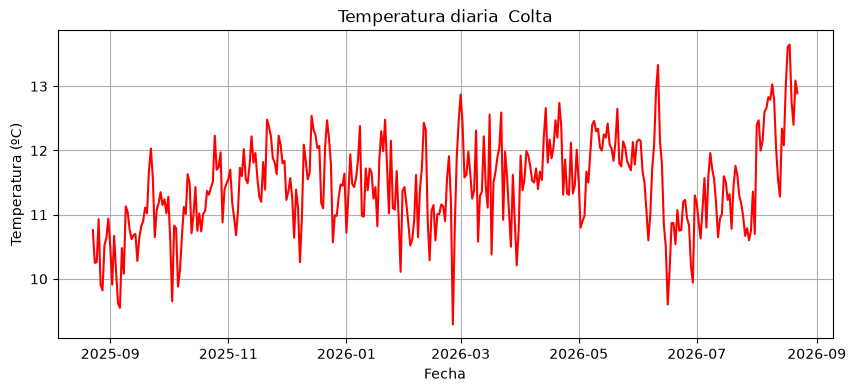

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(df['fecha'], df['T2M'], color='red')
plt.title('Temperatura diaria  Colta')
plt.xlabel('Fecha')
plt.ylabel('Temperatura (ºC)')
plt.grid(True)
plt.show()

## Graficos: PRECTOTCORR

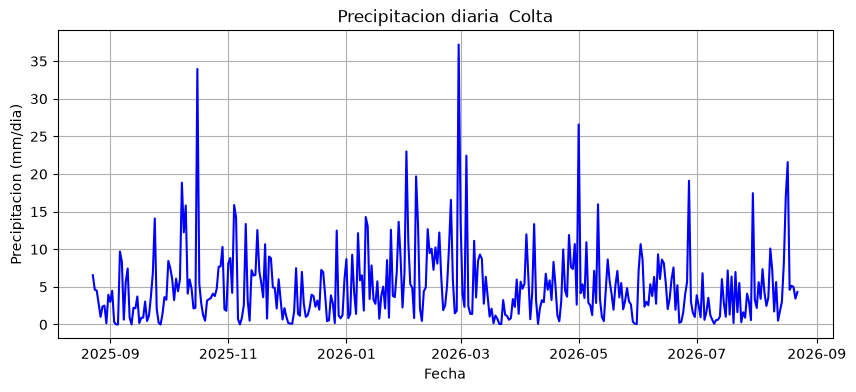

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(df['fecha'], df['PRECTOTCORR'], color='blue')
plt.title('Precipitacion diaria  Colta')
plt.xlabel('Fecha')
plt.ylabel('Precipitacion (mm/dia)')
plt.grid(True)
plt.show()

## Graficos: VPD

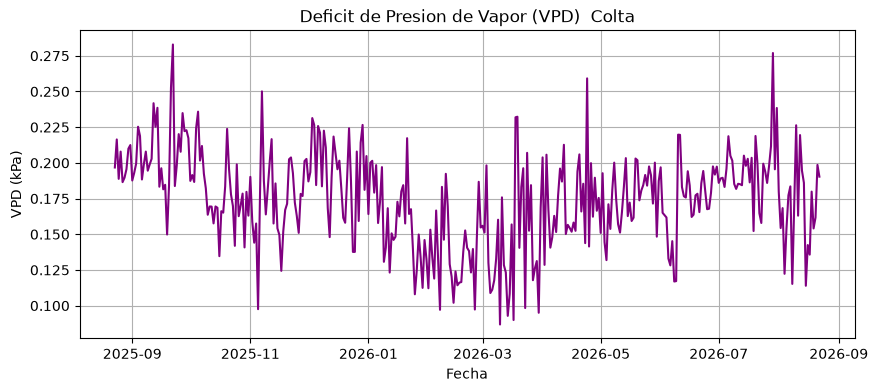

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(df['fecha'], df['VPD'], color='purple')
plt.title('Deficit de Presion de Vapor (VPD)  Colta')
plt.xlabel('Fecha')
plt.ylabel('VPD (kPa)')
plt.grid(True)
plt.show()

## Graficos: RH2M

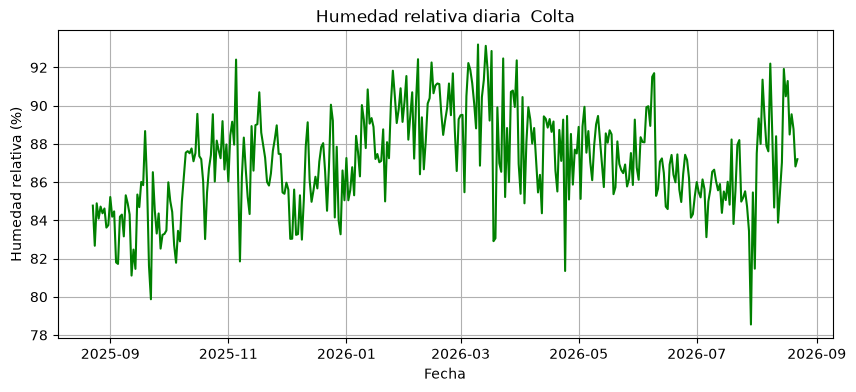

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(df['fecha'], df['RH2M'], color='green')
plt.title('Humedad relativa diaria  Colta')
plt.xlabel('Fecha')
plt.ylabel('Humedad relativa (%)')
plt.grid(True)
plt.show()

## Graficos: ALLSKY_SFC_SW_DWN

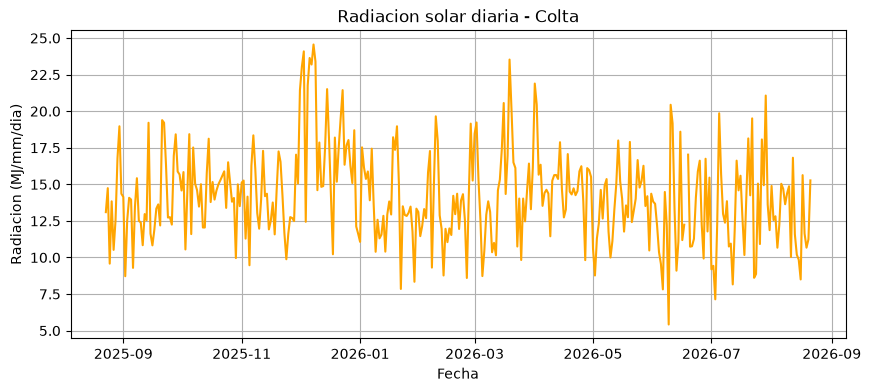

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(df['fecha'], df['ALLSKY_SFC_SW_DWN'], color='orange')
plt.title('Radiacion solar diaria - Colta')
plt.xlabel('Fecha')
plt.ylabel('Radiacion (MJ/mm/dia)')
plt.grid(True)
plt.show()

## Exportacion

In [30]:
df.to_csv('../data/processed/nasa_power_colta_12m_vpd_20250823_20260822.csv', index=False)

## Conclusiones

El dataset historico obtenido consta de un año de mediciones climaticas diarias obtenidas satisfactoriamente desde NASA POWER. No se han inventado datos ni interpolado anomalias. El VPD se calculo de forma exitosa y libre de saltos incongruentes.